# Simulate Auction

In [46]:
yr = 2027

In [47]:
annual_title = f"Modled Annual Auction Outcome for {yr}-{yr+1} BRA"
summer_title = f"Modeled Summer Auction Outcome for {yr}-{yr+1} BRA"
winter_title = f"Modeled Winter Auction Outcome for {yr}-{yr+1} BRA"

## Functions

### Imports

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### Functions

In [49]:
def process_contributions(results):
    # 1. Create 'Petroleum' by summing 'Distillate Oil (No.2)' and 'Oil'
    petro_mask = results['resource'].isin(['Distillate Oil (No.2)', 'Oil'])
    petro_offered = results.loc[petro_mask, 'offered'].sum()
    petro_cleared = results.loc[petro_mask, 'cleared'].sum()
    
    petro_row = pd.DataFrame([{
        'resource': 'Petroleum', 
        'offered': petro_offered, 
        'cleared': petro_cleared
    }])
    
    # 2. Split 'Gas' into Combined Cycle and Combustion Turbine
    gas_mask = results['resource'] == 'Gas'
    # Use .iloc[0] assuming there is only one "Gas" row to extract scalars
    gas_row = results[gas_mask]
    
    if not gas_row.empty:
        o_total = gas_row['offered'].iloc[0]
        c_total = gas_row['cleared'].iloc[0]
            
        # 1. Combined Cycle (The most efficient)
        cc_offered = o_total * 0.66
        # It clears as much as it can, up to its full offered capacity
        cc_cleared = min(cc_offered, c_total)
            
        # 2. Combustion Turbine (Middle efficiency)
        ct_offered = o_total * 0.30
        # It only clears what's left over after the CC units are satisfied
        remaining_cleared = max(0, c_total - cc_cleared)
        ct_cleared = min(ct_offered, remaining_cleared)
            
        # 3. Steam Turbine (Least efficient)
        st_offered = o_total - (cc_offered + ct_offered)
        # It gets the "scraps" - whatever cleared gas is left after CC and CT
        st_cleared = max(0, c_total - (cc_cleared + ct_cleared))
            
        gas_splits = pd.DataFrame([
            {'resource': 'Combined Cycle NG', 'offered': cc_offered, 'cleared': cc_cleared},
            {'resource': 'Combustion Turbine NG', 'offered': ct_offered, 'cleared': ct_cleared},
            {'resource': 'Steam Turbine NG', 'offered': st_offered, 'cleared': st_cleared}
        ])
    # 3. Create 'Offshore Wind' with zeros
    offshore_row = pd.DataFrame([{
        'resource': 'Offshore Wind', 
        'offered': 0, 
        'cleared': 0
    }])
    
    # Combine new rows and filter out the old rows (Oil and Gas)
    results = pd.concat([results, petro_row, gas_splits, offshore_row], ignore_index=True)

    sources_to_remove = ['Gas', 'Oil', 'Distillate Oil (No.2)']
    results = results[~results['resource'].isin(sources_to_remove)].copy()    

    # 4. Rename "Other" to "Biomass"
    results['resource'] = results['resource'].replace('Other', 'Biomass')

    return results.reset_index(drop=True)

def build_annual_vrr(prms): 
    # Build annual VRR curve given set of parameters
    # Convert DataFrame to a dictionary for easy access
    p = prms.set_index('parameter')['value'].to_dict()
    rr = float(p['reliability_requirement'])
    nc = float(p['netcone'])
    gc = float(p['grosscone']) # NOTE: this is in UCAP $/MW-day for 2025 and $/MW-yr for 2026 and 2027
    fpr = float(p['fpr'])
    frr = float(p['frr'])
    addback = float(p['addback'])

    if str(p['cap']) == 'x':
        # Point A: Greater of (Gross CONE or 1.5 * Net CONE) 
        # Based on your data: Gross CONE is 'price' (329.17) and Net CONE is 'cone'
        # Since your 2025 'cone' is a value, we use it here.        
        p_a = max(gc, 1.5 * nc) # NOTE: GC doesn't need to be changed 
        q_a = addback + ((rr - (frr * fpr)) * 0.989)
        
        p_b = (0.75 * nc) 
        q_b = addback + ((rr - (frr * fpr)) * 1.016)
        
        p_c = 0
        q_c = addback + ((rr - (frr * fpr)) * 1.068)
        
        points = [(0, p_a), (q_a, p_a), (q_b, p_b), (q_c, p_c), (1000000000000, p_c)]

    else: # 2026-2028 logic
        ferc_cap   = float(p['cap'])
        ferc_floor = float(p['floor'])
        
        # --- Standard tariff VRR anchor points ---
        p_a_calc = max(gc, 1.75 * nc)
        q_a      = addback + ((rr - (frr * fpr)) * 0.99)

        p_b      = 0.75 * nc
        q_b      = addback + ((rr - (frr * fpr)) * 1.015)

        p_c      = 0
        q_c      = addback + ((rr - (frr * fpr)) * 1.045)

        # 1. Handle the CAP (Point A segment)
        if p_a_calc > ferc_cap:
            m_ab = (p_b - p_a_calc) / (q_b - q_a)
            q_start = ((ferc_cap - p_a_calc) / m_ab) + q_a
            p_start = ferc_cap
        else:
            q_start = q_a
            p_start = p_a_calc

        # 2. Handle the FLOOR (Where the curve flattens out)
        # Check if floor hits on segment A-B or B-C
        if ferc_floor >= p_b:
            # Floor is high! Intersects segment A-B
            m_ab = (p_b - p_a_calc) / (q_b - q_a)
            q_end_int = ((ferc_floor - p_a_calc) / m_ab) + q_a
            
            points = [
                (0, p_start),
                (q_start, p_start),
                (q_end_int, ferc_floor),
                (q_c, ferc_floor), # Extend to q_c at floor price
                (1000000000000, ferc_floor)
            ]
        else:
            # Floor is low. Intersects segment B-C (Standard)
            m_bc = (p_c - p_b) / (q_c - q_b)
            q_floor_int = ((ferc_floor - p_b) / m_bc) + q_b
            
            points = [
                (0, p_start),
                (q_start, p_start),
                (q_b, p_b),
                (q_floor_int, ferc_floor),
                (q_c, ferc_floor),
                (1000000000000, ferc_floor)
            ]    # --- Store as DataFrame ---
    vrr_curve = pd.DataFrame(points, columns=['ucap_mw', 'price'])

    return vrr_curve

def build_summer_vrr(prms): 
    # Build annual VRR curve given set of parameters
    # Convert DataFrame to a dictionary for easy access
    p = prms.set_index('parameter')['value'].to_dict()
    nc = float(p['netcone'])
    gc = float(p['grosscone']) # NOTE: $/MW-day in 2025 and $/MW-yr in 2026 and 2027
    fpr = float(p['fpr'])
    frr = float(p['frr'])
    addback = float(p['addback'])


    peakdemand = float(p['peak'])
    fpr = float(p['fpr'])

    rr = peakdemand * fpr
    
    # We'll use a very large number for the 'infinity' end of the curve
    inf_q = rr * 2 

    if str(p['cap']) == 'x':
        # Point A: Greater of (Gross CONE or 1.5 * Net CONE) 
        # Based on your data: Gross CONE is 'price' (329.17) and Net CONE is 'cone'
        # Since your 2025 'cone' is a value, we use it here.        
        p_a = max(gc, 1.5 * nc) # NOTE: GC doesn't need to be changed 
        q_a = addback + ((rr - (frr * fpr)) * 0.989)
        
        p_b = (0.75 * nc) 
        q_b = addback + ((rr - (frr * fpr)) * 1.016)
        
        p_c = 0
        q_c = addback + ((rr - (frr * fpr)) * 1.068)
        
        points = [(0, p_a), (q_a, p_a), (q_b, p_b), (q_c, p_c), (1000000000000, p_c)]

    else: # 2026-2028 logic
                # Points based on your provided multipliers
                # p_a = max(Gross CONE, 1.75 * Net CONE) 
                # Using 'cap' (329.17) as Gross CONE and 'floor' (177.24) as Net CONE per your notes
        # --- CONE values (already in UCAP $/MW-day per your CSV) ---
        # --- FERC override cap/floor (already in UCAP $/MW-day in your CSV) ---
        ferc_cap   = float(p['cap'])
        ferc_floor = float(p['floor'])
        
        # --- Standard tariff VRR anchor points ---
        p_a_calc = max(gc, 1.75 * nc)   # NOTE: no /elcc since already UCAP
        q_a      = addback + ((rr - (frr * fpr)) * 0.99)

        p_b      = 0.75 * nc             # NOTE: no /elcc since already UCAP
        q_b      = addback + ((rr - (frr * fpr)) * 1.015)

        p_c      = 0          # floor, not zero
        q_c      = addback + ((rr - (frr * fpr)) * 1.045)

        m_bc        = (p_c - p_b) / (q_c - q_b)   # slope of B->C segment (p_c = 0)
        q_floor_int = ((ferc_floor - p_b) / m_bc) + q_b
        
        # 1. Handle the CAP (Point A segment)
        if p_a_calc > ferc_cap:
            m_ab = (p_b - p_a_calc) / (q_b - q_a)
            q_start = ((ferc_cap - p_a_calc) / m_ab) + q_a
            p_start = ferc_cap
        else:
            q_start = q_a
            p_start = p_a_calc

        # 2. Handle the FLOOR (Where the curve flattens out)
        # Check if floor hits on segment A-B or B-C
        if ferc_floor >= p_b:
            # Floor is high! Intersects segment A-B
            m_ab = (p_b - p_a_calc) / (q_b - q_a)
            q_end_int = ((ferc_floor - p_a_calc) / m_ab) + q_a
            
            points = [
                (0, p_start),
                (q_start, p_start),
                (q_end_int, ferc_floor),
                (q_c, ferc_floor), # Extend to q_c at floor price
                (1000000000000, ferc_floor)
            ]
        else:
            # Floor is low. Intersects segment B-C (Standard)
            m_bc = (p_c - p_b) / (q_c - q_b)
            q_floor_int = ((ferc_floor - p_b) / m_bc) + q_b
            
            points = [
                (0, p_start),
                (q_start, p_start),
                (q_b, p_b),
                (q_floor_int, ferc_floor),
                (q_c, ferc_floor),
                (1000000000000, ferc_floor)
            ]    # --- Store as DataFrame ---
    vrr_curve = pd.DataFrame(points, columns=['ucap_mw', 'price'])

    return vrr_curve

def build_winter_vrr(prms): 
    # Build annual VRR curve given set of parameters
    # Convert DataFrame to a dictionary for easy access
    p = prms.set_index('parameter')['value'].to_dict()
    nc = float(p['netcone'])
    gc = float(p['grosscone']) # NOTE: $/MW-day in 2025 and $/MW-yr in 2026 and 2027
    fpr = float(p['fpr'])
    frr = float(p['frr'])
    addback = float(p['addback'])

    peakdemand = float(p['winterpeak'])
    fpr = float(p['fpr'])
    rr = peakdemand * fpr
    print(f"WINTER RR: {rr - frr}")
    
    if str(p['cap']) == 'x':
        # Point A: Greater of (Gross CONE or 1.5 * Net CONE) 
        # Based on your data: Gross CONE is 'price' (329.17) and Net CONE is 'cone'
        # Since your 2025 'cone' is a value, we use it here.        
        p_a = max(gc, 1.5 * nc) # NOTE: GC doesn't need to be changed 
        q_a = addback + ((rr - (frr * fpr)) * 0.989)
        
        p_b = (0.75 * nc) 
        q_b = addback + ((rr - (frr * fpr)) * 1.016)
        
        p_c = 0
        q_c = addback + ((rr - (frr * fpr)) * 1.068)
        
        points = [(0, p_a), (q_a, p_a), (q_b, p_b), (q_c, p_c), (1000000000000, p_c)]

    else: # 2026-2028 logic
                # Points based on your provided multipliers
                # p_a = max(Gross CONE, 1.75 * Net CONE) 
                # Using 'cap' (329.17) as Gross CONE and 'floor' (177.24) as Net CONE per your notes
        # --- CONE values (already in UCAP $/MW-day per your CSV) ---
        # --- FERC override cap/floor (already in UCAP $/MW-day in your CSV) ---
        ferc_cap   = float(p['cap'])
        ferc_floor = float(p['floor'])
        
        # --- Standard tariff VRR anchor points ---
        p_a_calc = max(gc, 1.75 * nc)   # NOTE: no /elcc since already UCAP
        q_a      = addback + ((rr - (frr * fpr)) * 0.99)

        p_b      = 0.75 * nc             # NOTE: no /elcc since already UCAP
        q_b      = addback + ((rr - (frr * fpr)) * 1.015)

        p_c      = 0          # floor, not zero
        q_c      = addback + ((rr - (frr * fpr)) * 1.045)

        m_bc        = (p_c - p_b) / (q_c - q_b)   # slope of B->C segment (p_c = 0)
        q_floor_int = ((ferc_floor - p_b) / m_bc) + q_b
        
        # 1. Handle the CAP (Point A segment)
        if p_a_calc > ferc_cap:
            m_ab = (p_b - p_a_calc) / (q_b - q_a)
            q_start = ((ferc_cap - p_a_calc) / m_ab) + q_a
            p_start = ferc_cap
        else:
            q_start = q_a
            p_start = p_a_calc

        # 2. Handle the FLOOR (Where the curve flattens out)
        # Check if floor hits on segment A-B or B-C
        if ferc_floor >= p_b:
            # Floor is high! Intersects segment A-B
            m_ab = (p_b - p_a_calc) / (q_b - q_a)
            q_end_int = ((ferc_floor - p_a_calc) / m_ab) + q_a
            
            points = [
                (0, p_start),
                (q_start, p_start),
                (q_end_int, ferc_floor),
                (q_c, ferc_floor), # Extend to q_c at floor price
                (1000000000000, ferc_floor)
            ]
        else:
            # Floor is low. Intersects segment B-C (Standard)
            m_bc = (p_c - p_b) / (q_c - q_b)
            q_floor_int = ((ferc_floor - p_b) / m_bc) + q_b
            
            points = [
                (0, p_start),
                (q_start, p_start),
                (q_b, p_b),
                (q_floor_int, ferc_floor),
                (q_c, ferc_floor),
                (1000000000000, ferc_floor)
            ]    # --- Store as DataFrame ---
    vrr_curve = pd.DataFrame(points, columns=['ucap_mw', 'price'])

    return vrr_curve

def build_supply_curve(results, pjm_accreditation, prices, genx_accreditation=None):
    # --- 1. Map PJM accreditation (to recover ICAP) ---
    acc_map = (
        pjm_accreditation
        .assign(Accreditation=lambda x: x['Accreditation (%)'] / 100)
        .set_index('Generator Type')['Accreditation']
    )

    df = results.copy()
    df['pjm_elcc'] = df['resource'].map(acc_map)

    # --- Safety check: division by zero ---
    if (df['pjm_elcc'] == 0).any():
        zero_elcc = df.loc[df['pjm_elcc'] == 0, 'resource'].unique()
        raise ValueError(f"PJM ELCC is zero for resources: {zero_elcc}")

    # Recover ICAP (physical MW)
    df['icap_mw'] = df['offered'] / df['pjm_elcc']

    # --- 2. Expand into 1 MW ICAP chunks ---
    df['mw_int'] = df['icap_mw'].round().astype(int)
    expanded = df.loc[df.index.repeat(df['mw_int'])].copy()

    expanded['mw_rank'] = expanded.groupby(level=0).cumcount()
    expanded['group_size'] = expanded.groupby(level=0)['mw_int'].transform('first')
    expanded['quantile'] = (expanded['mw_rank'] + 0.5) / expanded['group_size']

    # --- 3. Pricing parameters (still ICAP space) ---
    pricing = prices.copy()
    pricing['mean'] = pricing['mid']
    pricing['sigma_low'] = (pricing['mid'] - pricing['low']) / 2
    pricing['sigma_high'] = (pricing['high'] - pricing['mid']) / 2
    pricing = pricing.set_index('Resource Class')

    expanded = expanded.join(
        pricing[['mean', 'sigma_low', 'sigma_high']],
        on='resource'
    )

    # --- Safety check: missing pricing information ---
    missing_prices = expanded.loc[expanded['mean'].isna(), 'resource'].unique()
    if len(missing_prices) > 0:
        raise ValueError(f"Pricing information missing for resources: {missing_prices}")

    # --- 4. Generate bids ($/ICAP) ---
    from scipy.stats import norm
    import numpy as np
    z = norm.ppf(expanded['quantile'].astype(float))

    expanded['bid_price_icap'] = np.clip(
        np.where(
            expanded['quantile'] < 0.5,
            expanded['mean'] + z * expanded['sigma_low'],
            expanded['mean'] + z * expanded['sigma_high']
        ),
        a_min=0,
        a_max=None
    )

    # --- 5. Apply YOUR accreditation (ICAP → UCAP) ---
    if genx_accreditation is not None:
        model_acc_map = (
            genx_accreditation
            .assign(Accreditation=lambda x: x['Accreditation (%)'] / 100)
            .set_index('Generator Type')['Accreditation']
        )
    else:
        model_acc_map = (
            pjm_accreditation
            .assign(Accreditation=lambda x: x['Accreditation (%)'] / 100)
            .set_index('Generator Type')['Accreditation']
        )

    # --- 5. Apply YOUR accreditation (ICAP → UCAP) ---
    # ... (keep your model_acc_map logic above) ...

    expanded['model_elcc'] = expanded['resource'].map(model_acc_map)

    # FIX 1: Each row represents 1 unit of ICAP. 
    # Its contribution to UCAP is the ELCC percentage itself.
    expanded['ucap_mw_step'] = expanded['model_elcc']

    # FIX 2: Convert price to UCAP space by DIVIDING. 
    # $/ICAP / (UCAP/ICAP) = $/UCAP
    expanded['bid_price_ucap'] = expanded['bid_price_icap'] / expanded['model_elcc']

    # --- 6. Build supply curve in UCAP space ---
    supply_curve = expanded.sort_values('bid_price_ucap').reset_index(drop=True)
    
    # FIX 3: Sum the individual UCAP steps, not the total plant capacity
    supply_curve['cumulative_mw'] = supply_curve['ucap_mw_step'].cumsum()

    return supply_curve

def find_market_clearing(supply_curve, vrr_curve):
    """
    Finds the intersection of the UCAP supply curve and the VRR demand curve.
    """
    # 1. Define the range of MWs to evaluate (from 0 to max supply)
    max_mw = supply_curve['cumulative_mw'].max()
    mw_steps = np.linspace(0, max_mw, 10000) # High resolution for accuracy

    # 2. Interpolate Demand Price (VRR) at these MW steps
    # xp = UCAP MW, fp = Price. np.interp handles the piecewise linear VRR perfectly.
    demand_prices = np.interp(
        mw_steps, 
        vrr_curve['ucap_mw'], 
        vrr_curve['price']
    )

    # 3. Interpolate Supply Price at these MW steps
    # Note: Supply is a step function, so we use 'left' side or nearest to be conservative
    supply_prices = np.interp(
        mw_steps, 
        supply_curve['cumulative_mw'], 
        supply_curve['bid_price_ucap']
    )

    # 4. Find where Supply >= Demand
    # We look for the first index where supply price crosses above the demand curve
    crossing_idx = np.where(supply_prices >= demand_prices)[0]

    if len(crossing_idx) > 0:
        clearing_idx = crossing_idx[0]
        clearing_price = demand_prices[clearing_idx]
        clearing_mw = mw_steps[clearing_idx]
    else:
        # If they never cross, the market clears at the end of the supply curve
        clearing_price = 0
        clearing_mw = max_mw

    return clearing_price, clearing_mw

def run_capacity_auction_analysis(supply_df, vrr_df, period_days=365, label="Scenario"):
    """
    Automates market clearing, expenditure calculation, and resource breakdown.
    """
    # 1. Find the market clearing intersection
    clearing_p, clearing_q = find_market_clearing(supply_df, vrr_df)

    # 2. Calculate Market Expenditures
    # Note: Using period_days for the duration calculation
    net_price_billions = (clearing_p * period_days * clearing_q) / 1e9

    # 3. Resource Breakdown Logic
    df_stats = supply_df.copy()
    
    # Identify cleared rows (using small epsilon for float precision)
    df_stats['is_cleared'] = df_stats['bid_price_ucap'] <= (clearing_p + 1e-5)

    # Group by resource
    resource_stats = df_stats.groupby('resource').apply(lambda x: pd.Series({
        'Offered_MW': x['ucap_mw_step'].sum(),
        'Cleared_MW': x.loc[x['is_cleared'], 'ucap_mw_step'].sum()
    }), include_groups=False).reset_index()

    # Calculate percentages and sort
    resource_stats['Percent_Cleared'] = (
        resource_stats['Cleared_MW'] / resource_stats['Offered_MW'] * 100
    ).round(2)
    resource_stats = resource_stats.sort_values('Offered_MW', ascending=False)

    # 4. Final Printout
    print(f"\n{'='*30}")
    print(f" RESULTS FOR: {label}")
    print(f"{'='*30}")
    print(f"Market Clearing Price:     ${clearing_p:,.2f}/MW-day")
    print(f"Market Clearing Quantity:  {clearing_q:,.2f} UCAP MW")
    print(f"Market Capacity Cost:      ${net_price_billions:,.2f} Billion ({period_days} days)")
    print("\n--- Resource Clearing Breakdown ---")
    print(resource_stats.to_string(index=False))
    
    return resource_stats, net_price_billions # Returning the stats in case you want to save them to CSV later

def plot_market_clearing(supply_df, vrr_df, title="Market Supply vs. Demand", price_limit=800):
    """
    Plots the supply bid distribution (scatter) against the VRR curve (line).
    """
    # 0. Basic Validation
    if supply_df.empty or vrr_df.empty:
        print(f"Warning: One of the DataFrames for '{title}' is empty. Cannot plot.")
        return

    # 1. Setup the Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    resources = supply_df['resource'].unique()
    colors = plt.cm.get_cmap('tab20', len(resources))
    
    # 2. Plot Supply Bids
    for i, res in enumerate(resources):
        subset = supply_df[supply_df['resource'] == res]
        ax.scatter(
            subset['cumulative_mw'], 
            subset['bid_price_ucap'], 
            label=res, 
            s=5, 
            alpha=0.6, 
            color=colors(i),
            edgecolors='none' # Faster rendering
        )

    # 3. Plot VRR Curve (Demand)
    ax.plot(
        vrr_df['ucap_mw'], 
        vrr_df['price'], 
        color='Blue', 
        linewidth=3, 
        label='VRR Curve (Demand)',
        zorder=10
    )

    # 4. Axis Scaling & Formatting
    max_q = vrr_df['ucap_mw'].max()
    ax.set_xlim(0, max_q * 1.05) 
    ax.set_ylim(0, price_limit) 
    
    ax.set_xlabel('Cumulative UCAP (MW)', fontweight='bold')
    ax.set_ylabel('Bid Price ($/MW-UCAP)', fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.legend(markerscale=3, loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    
    # Force display
    plt.show()

def plot_auction_results(annual_supply_curve, vrr_df, title):
    # 2. Setup the Plot
    plt.figure(figsize=(14, 8))
    resources = annual_supply_curve['resource'].unique()
    colors = plt.cm.get_cmap('tab20', len(resources))

    # 3. Plot each resource as a separate scatter group
    for i, res in enumerate(resources):
        subset = annual_supply_curve[annual_supply_curve['resource'] == res]
        plt.scatter(subset['cumulative_mw'], 
                    subset['bid_price_ucap'], 
                    label=res, 
                    s=2, 
                    alpha=0.5, 
                    color=colors(i))

    # --- NEW: Plot the VRR Curve ---
    # We plot this as a bold black line so it stands out against the scatter points
    plt.plot(vrr_df['ucap_mw'], 
            vrr_df['price'], 
            color='black', 
            linewidth=3, 
            label='VRR Curve (Demand)',
            zorder=10) # Ensures it sits on top of the dots

    # 4. Final Touches
    plt.xlabel('Cumulative UCAP (MW)')
    plt.ylabel('Bid Price ($/MW-day UCAP)')
    plt.title(title)

    # Optional: Set X-axis limit based on VRR Q_c point to keep the plot focused
    max_q = vrr_df['ucap_mw'].iloc[-2] # The last real point before the "infinity" point
    plt.xlim(0, max_q * 1.1) 

    plt.legend(markerscale=5, loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.2)
    plt.ylim(0, 800) 
    # ... (rest of your plotting code)
    
    plt.tight_layout()

    # 1. Sanitize the title to make it a valid filename (replaces spaces with underscores)
    filename = f"{title.replace(' ', '_')}.png"

    # 2. Save the figure before showing it
    plt.savefig(filename, dpi=300) # dpi=300 ensures high quality

    plt.show()


## Implementation

In [50]:
# Changeable
auction_year = yr
auction_bids = pd.read_csv(f"bids/fitted_icap_bids_5.csv") # 5 best

# Static
pjm_elcc = pd.read_csv(f"accreditation_values/pjm_{auction_year}.csv")
genx_annual_elcc = pd.read_csv(f"accreditation_values/genx_annual_2.csv")
genx_seasonal_elcc = pd.read_csv(f"accreditation_values/genx_seasonal.csv")

params = pd.read_csv(f"auction_params/{auction_year}.csv")

auction_contributions = pd.read_csv(f"auction_contributions/{auction_year}.csv")
contributions_edited = process_contributions(auction_contributions)


Annual PJM

In [51]:
pjm_annual_supply = build_supply_curve(contributions_edited, pjm_elcc, auction_bids)
_, real_annual_cost = run_capacity_auction_analysis(pjm_annual_supply, build_annual_vrr(params), 365, "PJM Annual")


 RESULTS FOR: PJM Annual
Market Clearing Price:     $240.27/MW-day
Market Clearing Quantity:  142,625.67 UCAP MW
Market Capacity Cost:      $12.51 Billion (365 days)

--- Resource Clearing Breakdown ---
             resource  Offered_MW  Cleared_MW  Percent_Cleared
    Combined Cycle NG    41448.14    39885.26            96.23
              Nuclear    30552.00    30552.00           100.00
                 Coal    30366.38    28023.29            92.28
Combustion Turbine NG    18839.85    17588.74            93.36
      Demand Response     7640.60     7640.60           100.00
        Hydroelectric     6002.10     6002.10           100.00
         Onshore Wind     4143.87     4143.87           100.00
            Petroleum     3588.00     3588.00           100.00
     Steam Turbine NG     2512.08     2512.08           100.00
                Solar     1480.96     1480.96           100.00
              Biomass     1005.12      942.48            93.77
      Battery Storage      204.74      2

Annual GenX

In [52]:
genx_annual_supply = build_supply_curve(contributions_edited, pjm_elcc, auction_bids, genx_annual_elcc)
_, genx_annual_cost =run_capacity_auction_analysis(genx_annual_supply, build_annual_vrr(params), 365, "GenX Annual")


 RESULTS FOR: GenX Annual
Market Clearing Price:     $333.44/MW-day
Market Clearing Quantity:  134,126.33 UCAP MW
Market Capacity Cost:      $16.32 Billion (365 days)

--- Resource Clearing Breakdown ---
             resource  Offered_MW  Cleared_MW  Percent_Cleared
    Combined Cycle NG  41112.0740  40816.2720            99.28
              Nuclear  29789.8080  29789.8080           100.00
                 Coal  26861.4412  25782.1672            95.98
Combustion Turbine NG  20486.0205  20247.2325            98.83
        Hydroelectric   5888.2140   5888.2140           100.00
         Onshore Wind   3492.9792   3492.9792           100.00
                Solar   2858.2528   2858.2528           100.00
            Petroleum   2111.4600   2111.4600           100.00
     Steam Turbine NG   2055.7188   2055.7188           100.00
              Biomass   1063.6124   1063.6124           100.00
      Battery Storage     63.4694     10.0688            15.86
      Demand Response      0.0000      

C:\Users\henry\AppData\Local\Temp\ipykernel_110660\3000543397.py:562: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(resources))


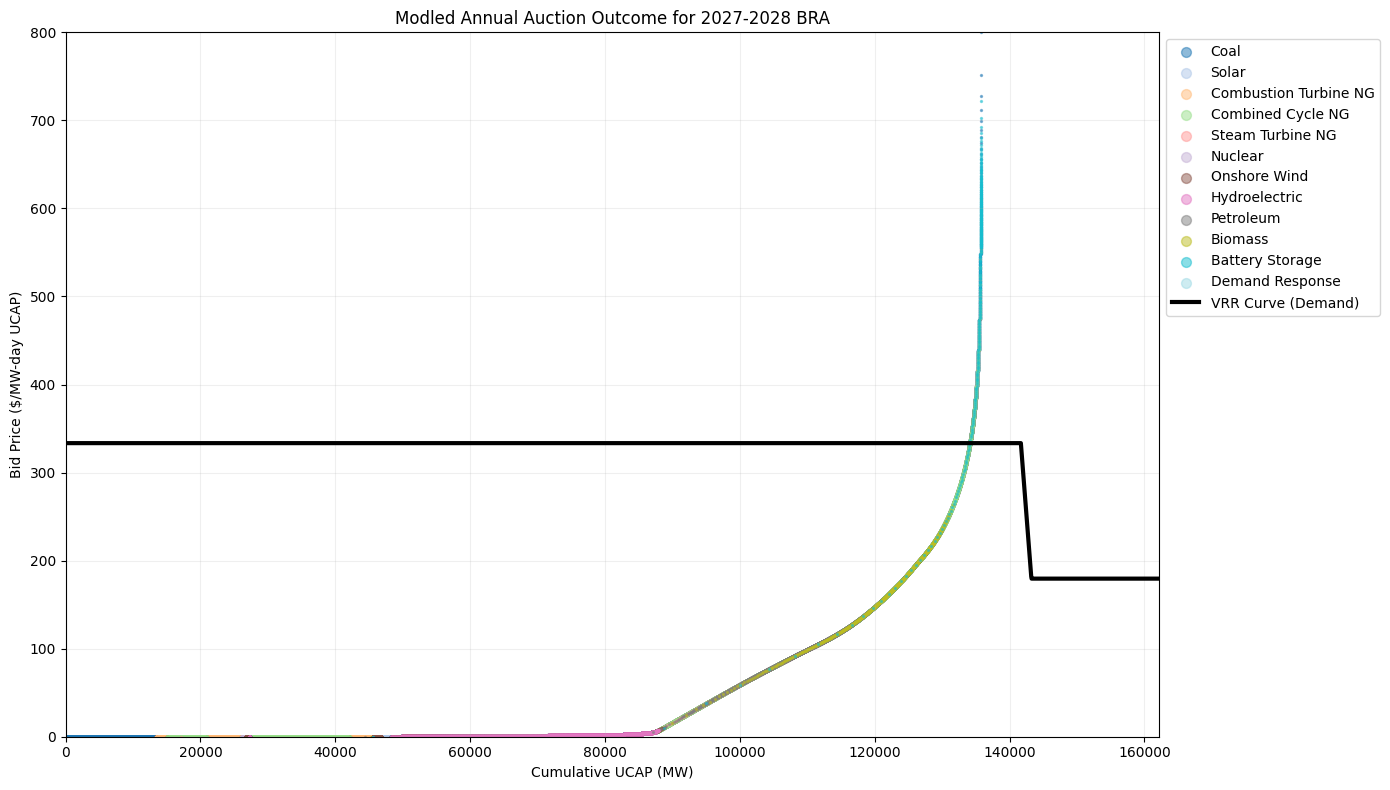

In [53]:
gxasc = build_supply_curve(contributions_edited, pjm_elcc, auction_bids, genx_annual_elcc)
avdv = build_annual_vrr(params) 

plot_auction_results(gxasc, avdv, annual_title)

Seasonal

In [54]:
# Create the Summer DataFrame
genx_summer_elcc = genx_seasonal_elcc[['Generator Type', 'Summer Accreditation (%)']].copy()
genx_summer_elcc.columns = ['Generator Type', 'Accreditation (%)']

# Create the Winter DataFrame
genx_winter_elcc = genx_seasonal_elcc[['Generator Type', 'Winter Accreditation (%)']].copy()
genx_winter_elcc.columns = ['Generator Type', 'Accreditation (%)']

In [55]:
summer_supply = build_supply_curve(contributions_edited, pjm_elcc, auction_bids, genx_summer_elcc)
_, summer_cost = run_capacity_auction_analysis(summer_supply, build_summer_vrr(params), 182.5, "Summer Seasonal")


 RESULTS FOR: Summer Seasonal
Market Clearing Price:     $279.66/MW-day
Market Clearing Quantity:  142,226.37 UCAP MW
Market Capacity Cost:      $7.26 Billion (182.5 days)

--- Resource Clearing Breakdown ---
             resource  Offered_MW  Cleared_MW  Percent_Cleared
    Combined Cycle NG  50174.6538  49867.3944            99.39
              Nuclear  29194.8480  29194.8480           100.00
                 Coal  27146.8120  25269.5520            93.08
Combustion Turbine NG  23420.0955  23073.5524            98.52
                Solar   5768.3392   5768.3392           100.00
        Hydroelectric   5423.4360   5423.4360           100.00
         Onshore Wind   1849.5810   1849.5810           100.00
              Biomass   1184.2268   1184.2268           100.00
     Steam Turbine NG    719.4318    433.4324            60.25
      Battery Storage    140.3175    121.6350            86.69
            Petroleum      3.9000      0.0010             0.03
      Demand Response      0.0000 

In [56]:
winter_supply = build_supply_curve(contributions_edited, pjm_elcc, auction_bids, genx_winter_elcc)
_, winter_cost =run_capacity_auction_analysis(winter_supply, build_winter_vrr(params), 182.5, "Winter Seasonal")

WINTER RR: 131357.73200000002

 RESULTS FOR: Winter Seasonal
Market Clearing Price:     $333.44/MW-day
Market Clearing Quantity:  130,065.17 UCAP MW
Market Capacity Cost:      $7.91 Billion (182.5 days)

--- Resource Clearing Breakdown ---
             resource  Offered_MW  Cleared_MW  Percent_Cleared
    Combined Cycle NG  37387.3425  36900.7350            98.70
              Nuclear  30034.2240  30034.2240           100.00
                 Coal  26740.7074  25648.0119            95.91
Combustion Turbine NG  19278.4170  18962.5718            98.36
        Hydroelectric   6079.0500   6079.0500           100.00
         Onshore Wind   4168.1268   4168.1268           100.00
            Petroleum   2977.6500   2977.6500           100.00
     Steam Turbine NG   2605.2363   2605.2363           100.00
                Solar   1662.3776   1662.3776           100.00
              Biomass   1014.0544   1014.0544           100.00
      Battery Storage     31.8759      1.2642             3.97
    

C:\Users\henry\AppData\Local\Temp\ipykernel_110660\3000543397.py:562: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(resources))


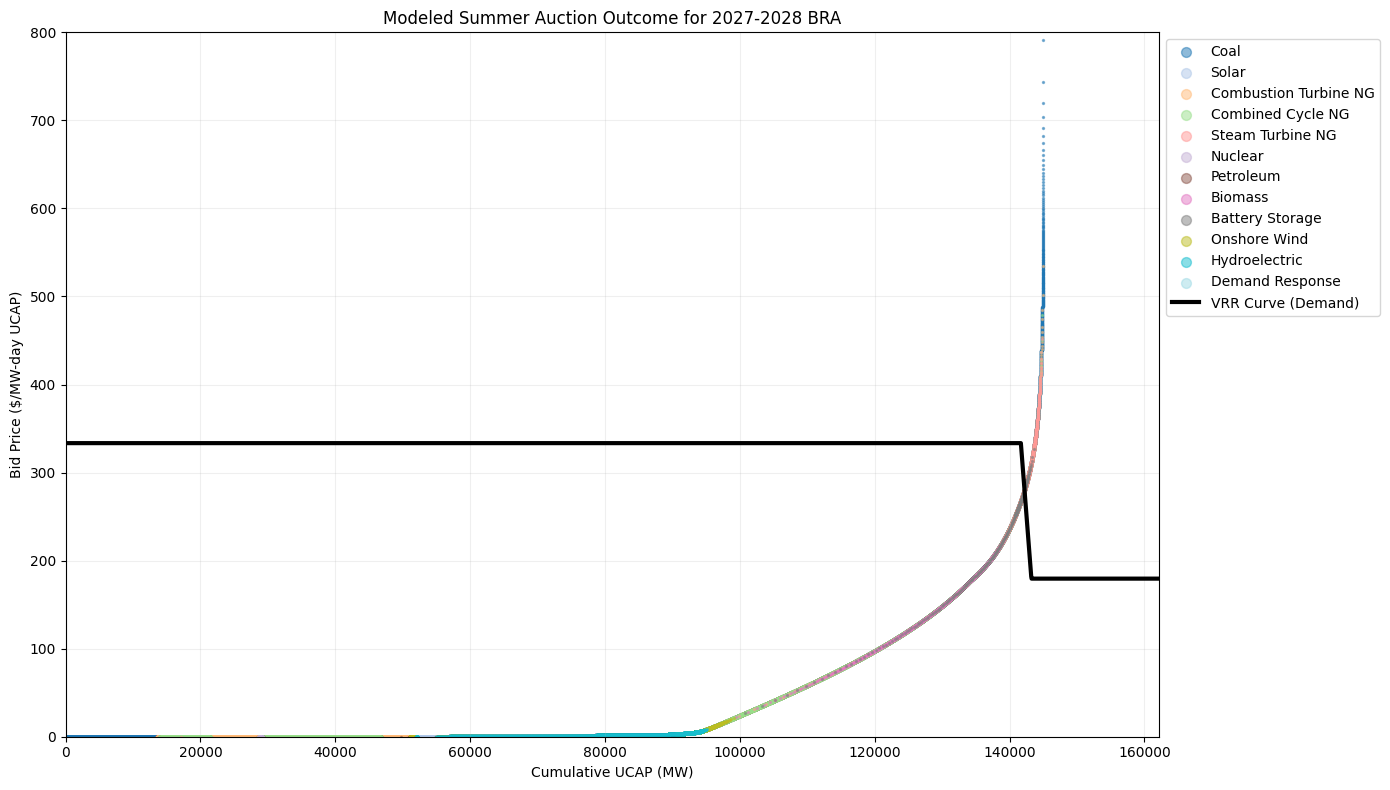

WINTER RR: 131357.73200000002


C:\Users\henry\AppData\Local\Temp\ipykernel_110660\3000543397.py:562: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(resources))


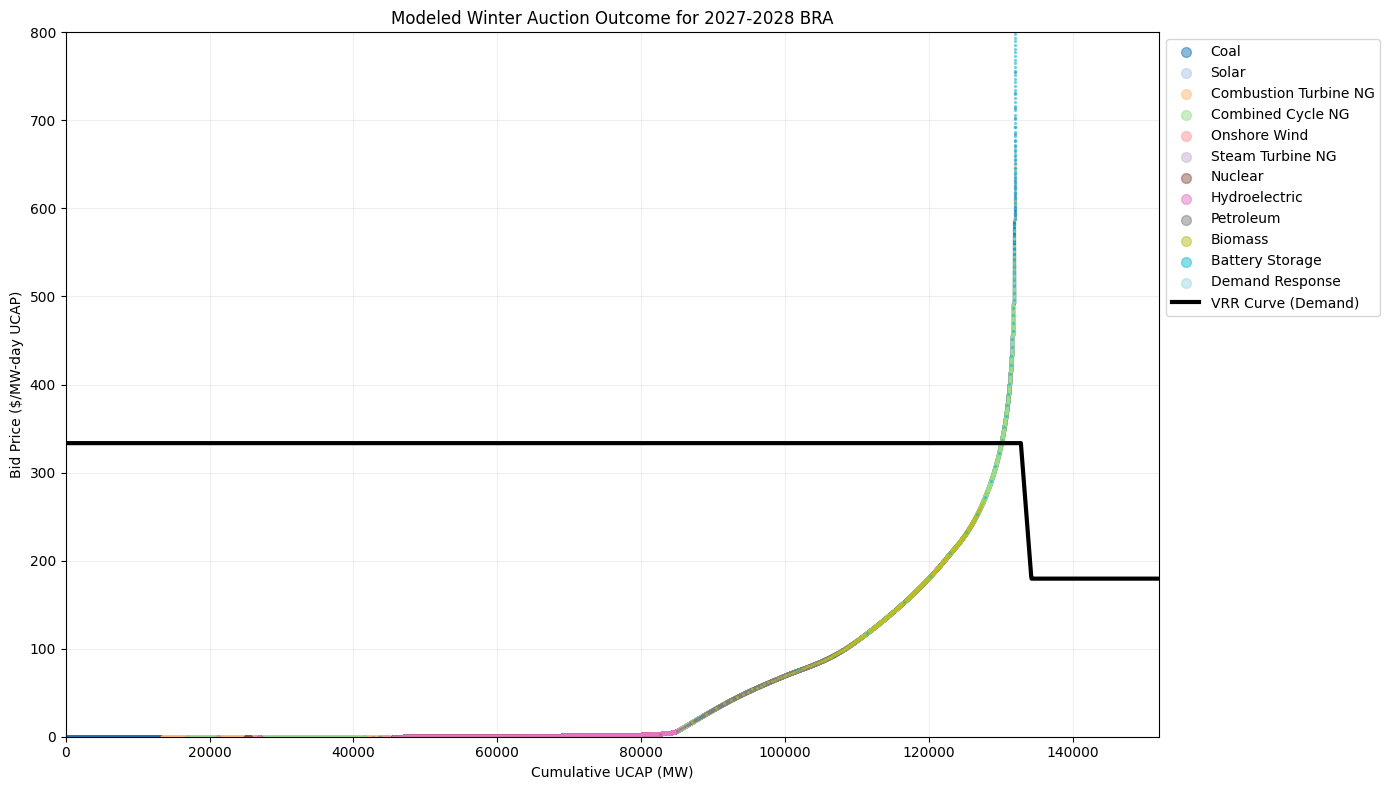

In [57]:
gxssc = build_supply_curve(contributions_edited, pjm_elcc, auction_bids, genx_summer_elcc)
svdv = build_summer_vrr(params)
plot_auction_results(gxssc, svdv, summer_title)

gxwsc = build_supply_curve(contributions_edited, pjm_elcc, auction_bids, genx_winter_elcc)
wvdv = build_winter_vrr(params)
plot_auction_results(gxwsc, wvdv, winter_title)

In [58]:
print(f"==========================\n {yr} Annual Cost Comparison \n==========================")
print(f"PJM Annual Cost: ${real_annual_cost:,.2f} Billion")
print(f"GenX Annual Cost: ${genx_annual_cost:,.2f} Billion")
print(f"Seasonal Annual Cost: ${(summer_cost + winter_cost):,.2f} Billion")

 2027 Annual Cost Comparison 
PJM Annual Cost: $12.51 Billion
GenX Annual Cost: $16.32 Billion
Seasonal Annual Cost: $15.17 Billion


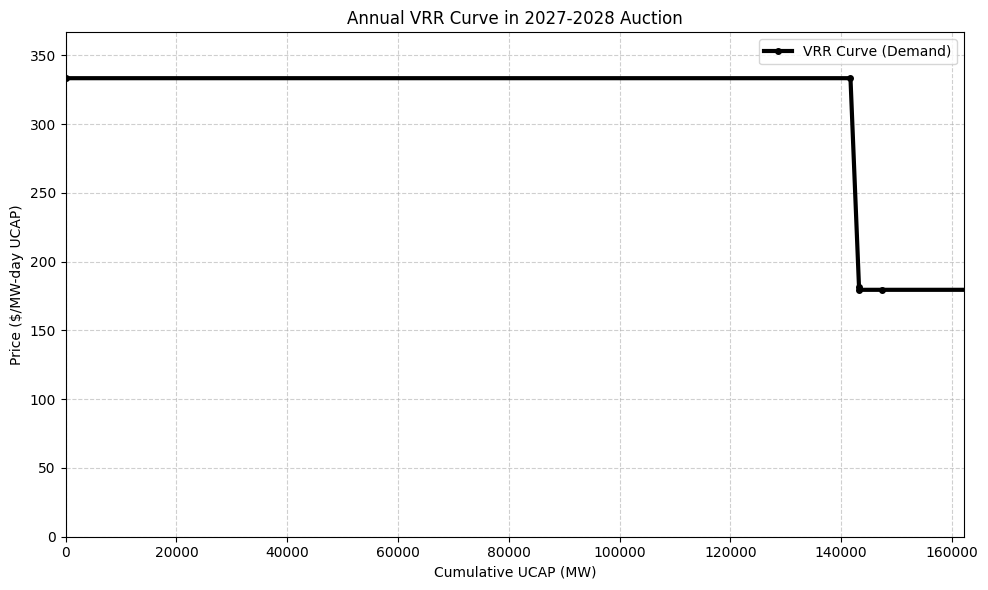

In [59]:

def plot_vrr_only(vrr_df, title="VRR Curve (Demand)"):
    """
    Plots only the VRR (Demand) curve from the provided DataFrame.
    """
    # 1. Setup the Plot
    plt.figure(figsize=(10, 6))

    # 2. Plot the VRR Curve
    # We use a solid black line with markers to indicate the specific price points
    plt.plot(vrr_df['ucap_mw'], 
             vrr_df['price'], 
             color='black', 
             linewidth=3, 
             marker='o',
             markersize=4,
             label='VRR Curve (Demand)')

    # 3. Final Touches
    plt.xlabel('Cumulative UCAP (MW)')
    plt.ylabel('Price ($/MW-day UCAP)')
    plt.title(title)

    # Set X-axis limit based on the VRR Q_c point
    # Assuming the second to last point represents the target capacity
    max_q = vrr_df['ucap_mw'].iloc[-2] if len(vrr_df) > 1 else vrr_df['ucap_mw'].max()
    plt.xlim(0, max_q * 1.1) 
    
    # Set Y-axis limit (Adjust 800 based on your specific market cap if needed)
    plt.ylim(0, vrr_df['price'].max() * 1.1) 

    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # 4. Save and Show
    filename = f"{title.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

plot_vrr_only(build_annual_vrr(params), f"Annual VRR Curve in {yr}-{yr+1} Auction")

C:\Users\henry\AppData\Local\Temp\ipykernel_110660\3243653273.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(resources))


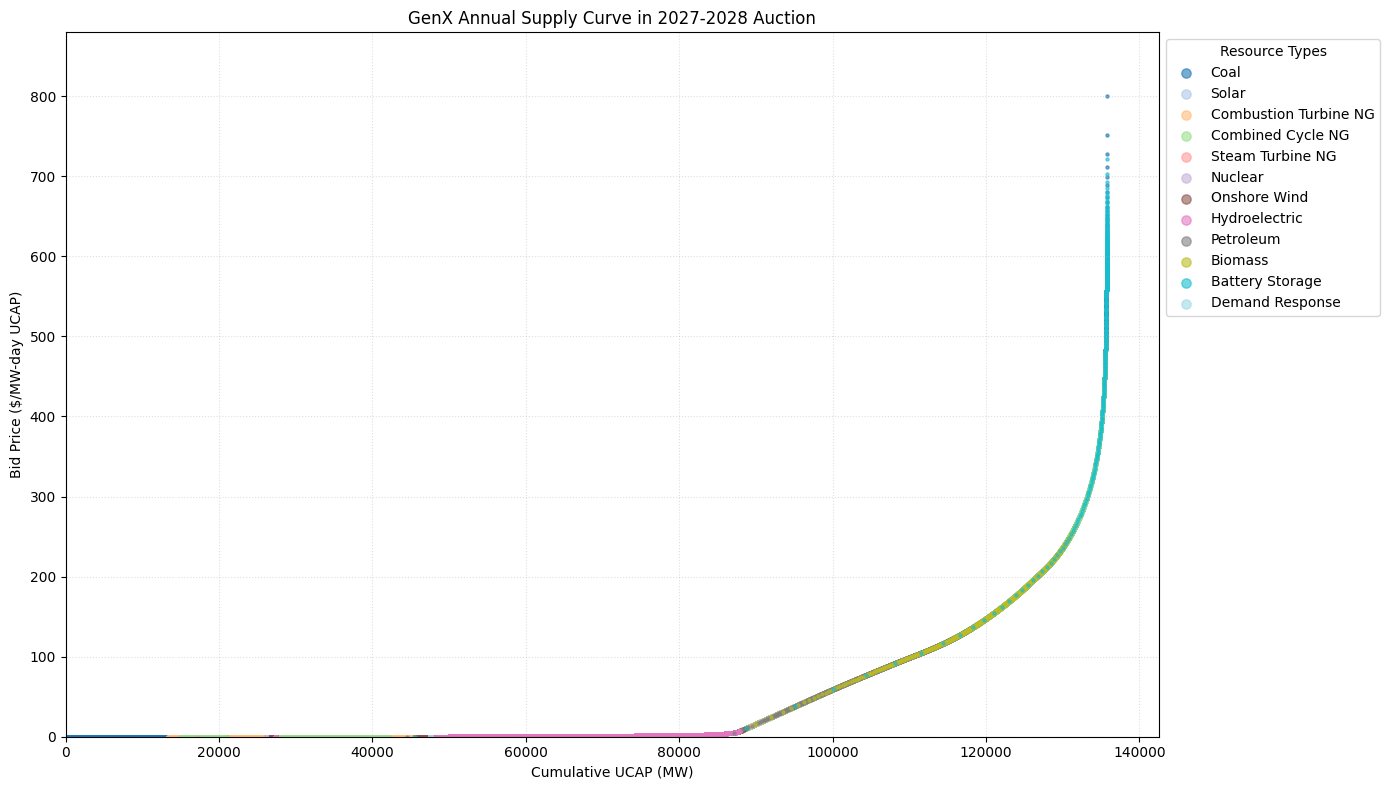

In [60]:
import matplotlib.pyplot as plt

def plot_supply_only(annual_supply_curve, title="Supply Curve"):
    """
    Plots only the Supply curve (bids) from the provided DataFrame.
    """
    # 1. Setup the Plot
    plt.figure(figsize=(14, 8))
    
    # Get unique resources and assign colors
    resources = annual_supply_curve['resource'].unique()
    colors = plt.cm.get_cmap('tab20', len(resources))

    # 2. Plot each resource as a separate scatter group
    # Using scatter allows us to see individual bid points and how they cluster
    for i, res in enumerate(resources):
        subset = annual_supply_curve[annual_supply_curve['resource'] == res]
        plt.scatter(subset['cumulative_mw'], 
                    subset['bid_price_ucap'], 
                    label=res, 
                    s=5,           # Increased size slightly for visibility
                    alpha=0.6,     # Slightly higher opacity since there's no VRR line
                    color=colors(i))

    # 3. Final Touches
    plt.xlabel('Cumulative UCAP (MW)')
    plt.ylabel('Bid Price ($/MW-day UCAP)')
    plt.title(title)

    # Set axis limits
    plt.xlim(0, annual_supply_curve['cumulative_mw'].max() * 1.05)
    plt.ylim(0, annual_supply_curve['bid_price_ucap'].max() * 1.1)

    # Place legend outside to avoid covering data points
    plt.legend(markerscale=3, loc='upper left', bbox_to_anchor=(1, 1), title="Resource Types")
    plt.grid(True, linestyle=':', alpha=0.4)
    
    plt.tight_layout()

    # 4. Save and Show
    filename = f"{title.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()

plot_supply_only(genx_annual_supply, f"GenX Annual Supply Curve in {yr}-{yr+1} Auction")

In [63]:
def build_summer_vrr_no_hyperscale(prms, auction_year, remove_hyperscale=True):

    """
    Build summer VRR curve with optional removal of hyperscaler-driven load.

    Parameters:
        prms (DataFrame): parameter table
        auction_year (int): 2026 or 2027
        remove_hyperscale (bool): whether to remove hyperscaler load

    Returns:
        vrr_curve (DataFrame)
    """

    # -------------------------
    # Hyperscaler Load Impacts
    # -------------------------

    hyperscaler_load = {
        2026: 7892,    # MW — 2026/27 BRA
        2027: 13688    # MW — 2027/28 BRA
    }

    # -------------------------
    # Convert parameters
    # -------------------------

    p = prms.set_index('parameter')['value'].to_dict()

    nc = float(p['netcone'])
    gc = float(p['grosscone'])
    fpr = float(p['fpr'])
    frr = float(p['frr'])
    addback = float(p['addback'])

    peakdemand = float(p['peak'])

    # -------------------------
    # Remove hyperscaler load
    # -------------------------

    if remove_hyperscale and auction_year in hyperscaler_load:
        peakdemand_adj = peakdemand - hyperscaler_load[auction_year]
    else:
        peakdemand_adj = peakdemand

    rr = peakdemand_adj * fpr

    inf_q = rr * 2

    # =====================================================
    # 2025 logic (unchanged)
    # =====================================================

    if str(p['cap']) == 'x':

        p_a = max(gc, 1.5 * nc)

        q_a = addback + ((rr - (frr * fpr)) * 0.989)

        p_b = 0.75 * nc
        q_b = addback + ((rr - (frr * fpr)) * 1.016)

        p_c = 0
        q_c = addback + ((rr - (frr * fpr)) * 1.068)

        points = [
            (0, p_a),
            (q_a, p_a),
            (q_b, p_b),
            (q_c, p_c),
            (1000000000000, p_c)
        ]

    # =====================================================
    # 2026–2028 logic
    # =====================================================

    else:

        ferc_cap   = float(p['cap'])
        ferc_floor = float(p['floor'])

        p_a_calc = max(gc, 1.75 * nc)

        q_a = addback + ((rr - (frr * fpr)) * 0.99)

        p_b = 0.75 * nc
        q_b = addback + ((rr - (frr * fpr)) * 1.015)

        p_c = 0
        q_c = addback + ((rr - (frr * fpr)) * 1.045)

        # Handle CAP

        if p_a_calc > ferc_cap:

            m_ab = (p_b - p_a_calc) / (q_b - q_a)

            q_start = ((ferc_cap - p_a_calc) / m_ab) + q_a

            p_start = ferc_cap

        else:

            q_start = q_a
            p_start = p_a_calc

        # Handle FLOOR

        if ferc_floor >= p_b:

            m_ab = (p_b - p_a_calc) / (q_b - q_a)

            q_end_int = ((ferc_floor - p_a_calc) / m_ab) + q_a

            points = [

                (0, p_start),

                (q_start, p_start),

                (q_end_int, ferc_floor),

                (q_c, ferc_floor),

                (1000000000000, ferc_floor)

            ]

        else:

            m_bc = (p_c - p_b) / (q_c - q_b)

            q_floor_int = ((ferc_floor - p_b) / m_bc) + q_b

            points = [

                (0, p_start),

                (q_start, p_start),

                (q_b, p_b),

                (q_floor_int, ferc_floor),

                (q_c, ferc_floor),

                (1000000000000, ferc_floor)

            ]

    vrr_curve = pd.DataFrame(points, columns=['ucap_mw', 'price'])

    return vrr_curve

In [62]:
_, genx_annual_cost =run_capacity_auction_analysis(genx_annual_supply, build_summer_vrr_no_hyperscale(params, yr), 365, "No Hyperscalers")


 RESULTS FOR: No Hyperscalers
Market Clearing Price:     $241.15/MW-day
Market Clearing Quantity:  130,432.66 UCAP MW
Market Capacity Cost:      $11.48 Billion (365 days)

--- Resource Clearing Breakdown ---
             resource  Offered_MW  Cleared_MW  Percent_Cleared
    Combined Cycle NG  41112.0740  39535.4420            96.17
              Nuclear  29789.8080  29789.8080           100.00
                 Coal  26861.4412  24094.9756            89.70
Combustion Turbine NG  20486.0205  19452.5991            94.96
        Hydroelectric   5888.2140   5888.2140           100.00
         Onshore Wind   3492.9792   3492.9792           100.00
                Solar   2858.2528   2858.2528           100.00
            Petroleum   2111.4600   2111.4600           100.00
     Steam Turbine NG   2055.7188   2055.7188           100.00
              Biomass   1063.6124   1050.6601            98.78
      Battery Storage     63.4694      5.0344             7.93
      Demand Response      0.0000  